#### Graph inspector
Demonstration of the functionality in GraphInspector. Rough overview of implemented features:
- Graph visualization: Mesh, Grid, Encoder, Decoder
- Checking for orphans: Quickcheck and plotting
- Edge weights statistics

In [16]:
%load_ext autoreload
%autoreload 2
from GraphInspector import GraphInspector
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import warnings
from matplotlib.colors import LinearSegmentedColormap

# Suppress RuntimeWarnings from Shapely
warnings.filterwarnings("ignore", category=RuntimeWarning)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
path_to_graph = 'graph10.3.pt'

graph = GraphInspector(path_to_graph, grid_key = 'data', hidden_key = 'hidden', coords_key='x')
xlim = (-30,60)
ylim=(50,90)


#### Graph visualization
The graph visualization tools are all set up to return (fig, ax), as this makes it slighly easier to adjust xlim and ylim without having to re-generate the plot. You can also specify xlim, ylim and save_path.

(<Figure size 1200x600 with 1 Axes>, <GeoAxes: >)

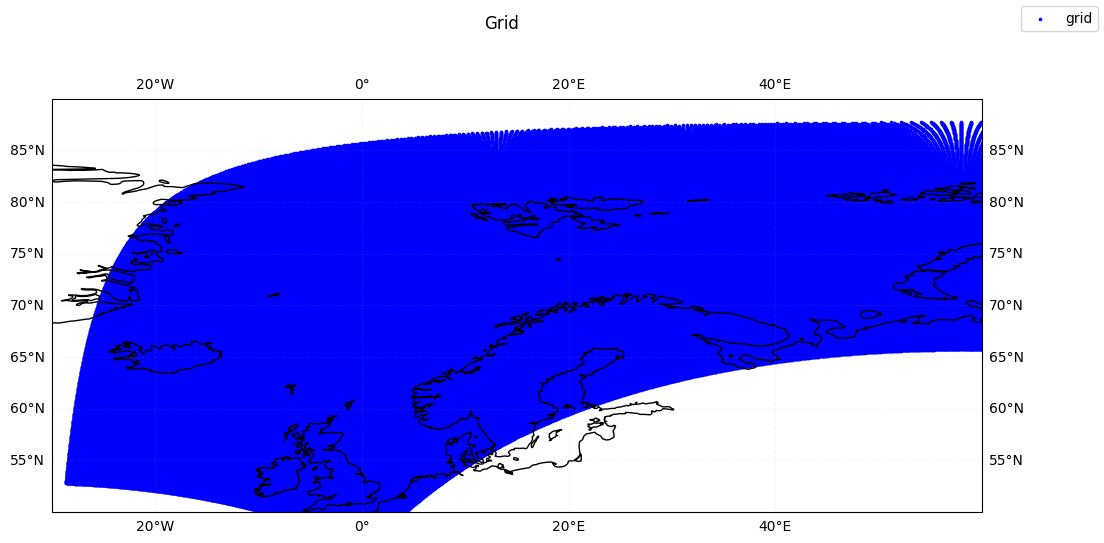

In [4]:
# Grid

graph.plot_grid(xlim=xlim, ylim=ylim)

In [18]:

mesh_edge_lons = np.array(graph.mesh_edge_list[1], dtype=object)
mesh_edge_lats = np.array(graph.mesh_edge_list[0], dtype=object)

n_lines = graph.graph_data[graph.h2h_key]['edge_index'].shape[1]
edge_weights = graph.mesh_edge_weights

In [19]:
# Function to apply the thresholds
def apply_threshold(value, lower_threshold, upper_threshold):
    if value is None:  # If the value is None, leave it as is
        return None
    if value < lower_threshold or value > upper_threshold:  # Apply threshold
        return None
    return value

# Use np.vectorize to apply the function element-wise
mesh_edge_lons_large = mesh_edge_lons
mesh_edge_lons_large = np.vectorize(apply_threshold)(mesh_edge_lons_large, -14, 25)
mesh_edge_lats_large = mesh_edge_lats
mesh_edge_lats_large = np.vectorize(apply_threshold)(mesh_edge_lats_large, 57, 71)
mesh_edge_lons_small = mesh_edge_lons
mesh_edge_lons_small = np.vectorize(apply_threshold)(mesh_edge_lons_small, -2, 2)
mesh_edge_lats_small = mesh_edge_lats
mesh_edge_lats_small = np.vectorize(apply_threshold)(mesh_edge_lats_small, 65, 66)


In [ ]:
def get_color(weight, cmap):
    #print(weight)
    if weight > 30:
        return cmap[0], 15, 1
    elif weight <= 30 and weight > 15:
        return cmap[1], 8, 2
    elif weight <= 15 and weight > 7:
        return cmap[2], 3.5, 3
    elif weight <= 17 and weight > 15:
        return cmap[3], 1, 4
    elif weight <= 15 and weight > 7:
        return cmap[4], 0.5,5
    elif weight <= 7 and weight > 4:
        return cmap[5], 0.25, 6
    else:
        return cmap[6], 0.1, 7 

: 

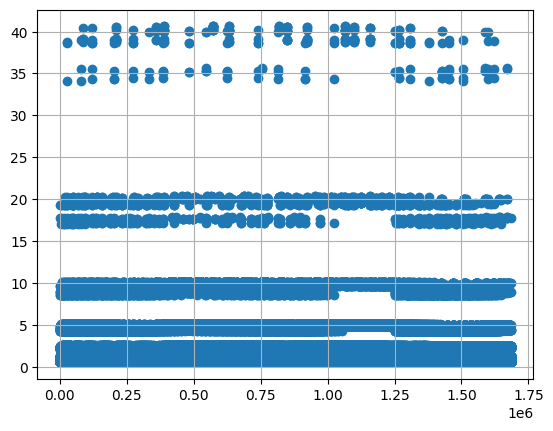

: 

In [ ]:
cmap = plt.get_cmap('tab10', n_lines)
norm = mcolors.Normalize(vmin=min(edge_weights), vmax=max(edge_weights))

plt.scatter(np.linspace(1,len(edge_weights), len(edge_weights)), edge_weights)
plt.grid()

In [ ]:
fig, ax = plt.subplots(figsize=(10,10), dpi=200)
ax.scatter(graph.mesh_lons, graph.mesh_lats, marker='.', s=10, color='grey', label = 'Hidden mesh', zorder=50, alpha=0.4)

cmap = ['#1A237E', '#0288D1', '#4CAF50', '#9C27B0', '#FF9800', '#F44336', '#00E5FF']
ax.set_ylim(65.5, 67)
ax.set_xlim(-2,2)
for i in range(n_lines):
    if edge_weights[i] > 8:
        pass
    else:
        color, lw, zorder = get_color(edge_weights[i], cmap=cmap)
        ax.plot(mesh_edge_lons_small[3*i:3*i+2], mesh_edge_lats_small[3*i:3*i+2], lw=lw, zorder=zorder, color=color)#, transform=ccrs.PlateCarree())

custom_cmap = LinearSegmentedColormap.from_list("CustomCmap", cmap, N=7)
norm = mcolors.Normalize(vmin=1, vmax=8)

sm = cm.ScalarMappable(cmap=custom_cmap, norm=norm)
cax = fig.add_axes([ax.get_position().x1+0.07,ax.get_position().y0+0.01,0.02,ax.get_position().height-0.02])
cbar = fig.colorbar(sm, cax=cax, ticks=[1.5,2.5,3.5,4.5,5.5,6.5,7.5], label='Refinement level')
cbar.ax.set_yticklabels(["4", "5", "6", "7", "8", "9", "10"])
#ax.set_extent([-2,2,65.5,67])
legend = ax.legend(loc='upper right', fontsize=12, framealpha=0.9)
legend.set_zorder(150)
for handle in legend.legend_handles:
    handle.set_sizes([50])

label_style = {'size': 12, 'color': 'gray'}
#gl = ax.gridlines(crs=ccrs.PlateCarree(), color='black', draw_labels=True, dms=True, x_inline=False, y_inline=False, zorder=200)
#gl.top_labels = gl.right_labels = False
#gl.xlabel_style = label_style
#gl.ylabel_style = label_style
#gl.rotate_labels = False
#gl.xlines = gl.ylines = None
#ax.gridlines(crs=ccrs.PlateCarree(), color='grey', draw_labels=False, x_inline=False, y_inline=False, zorder=0)


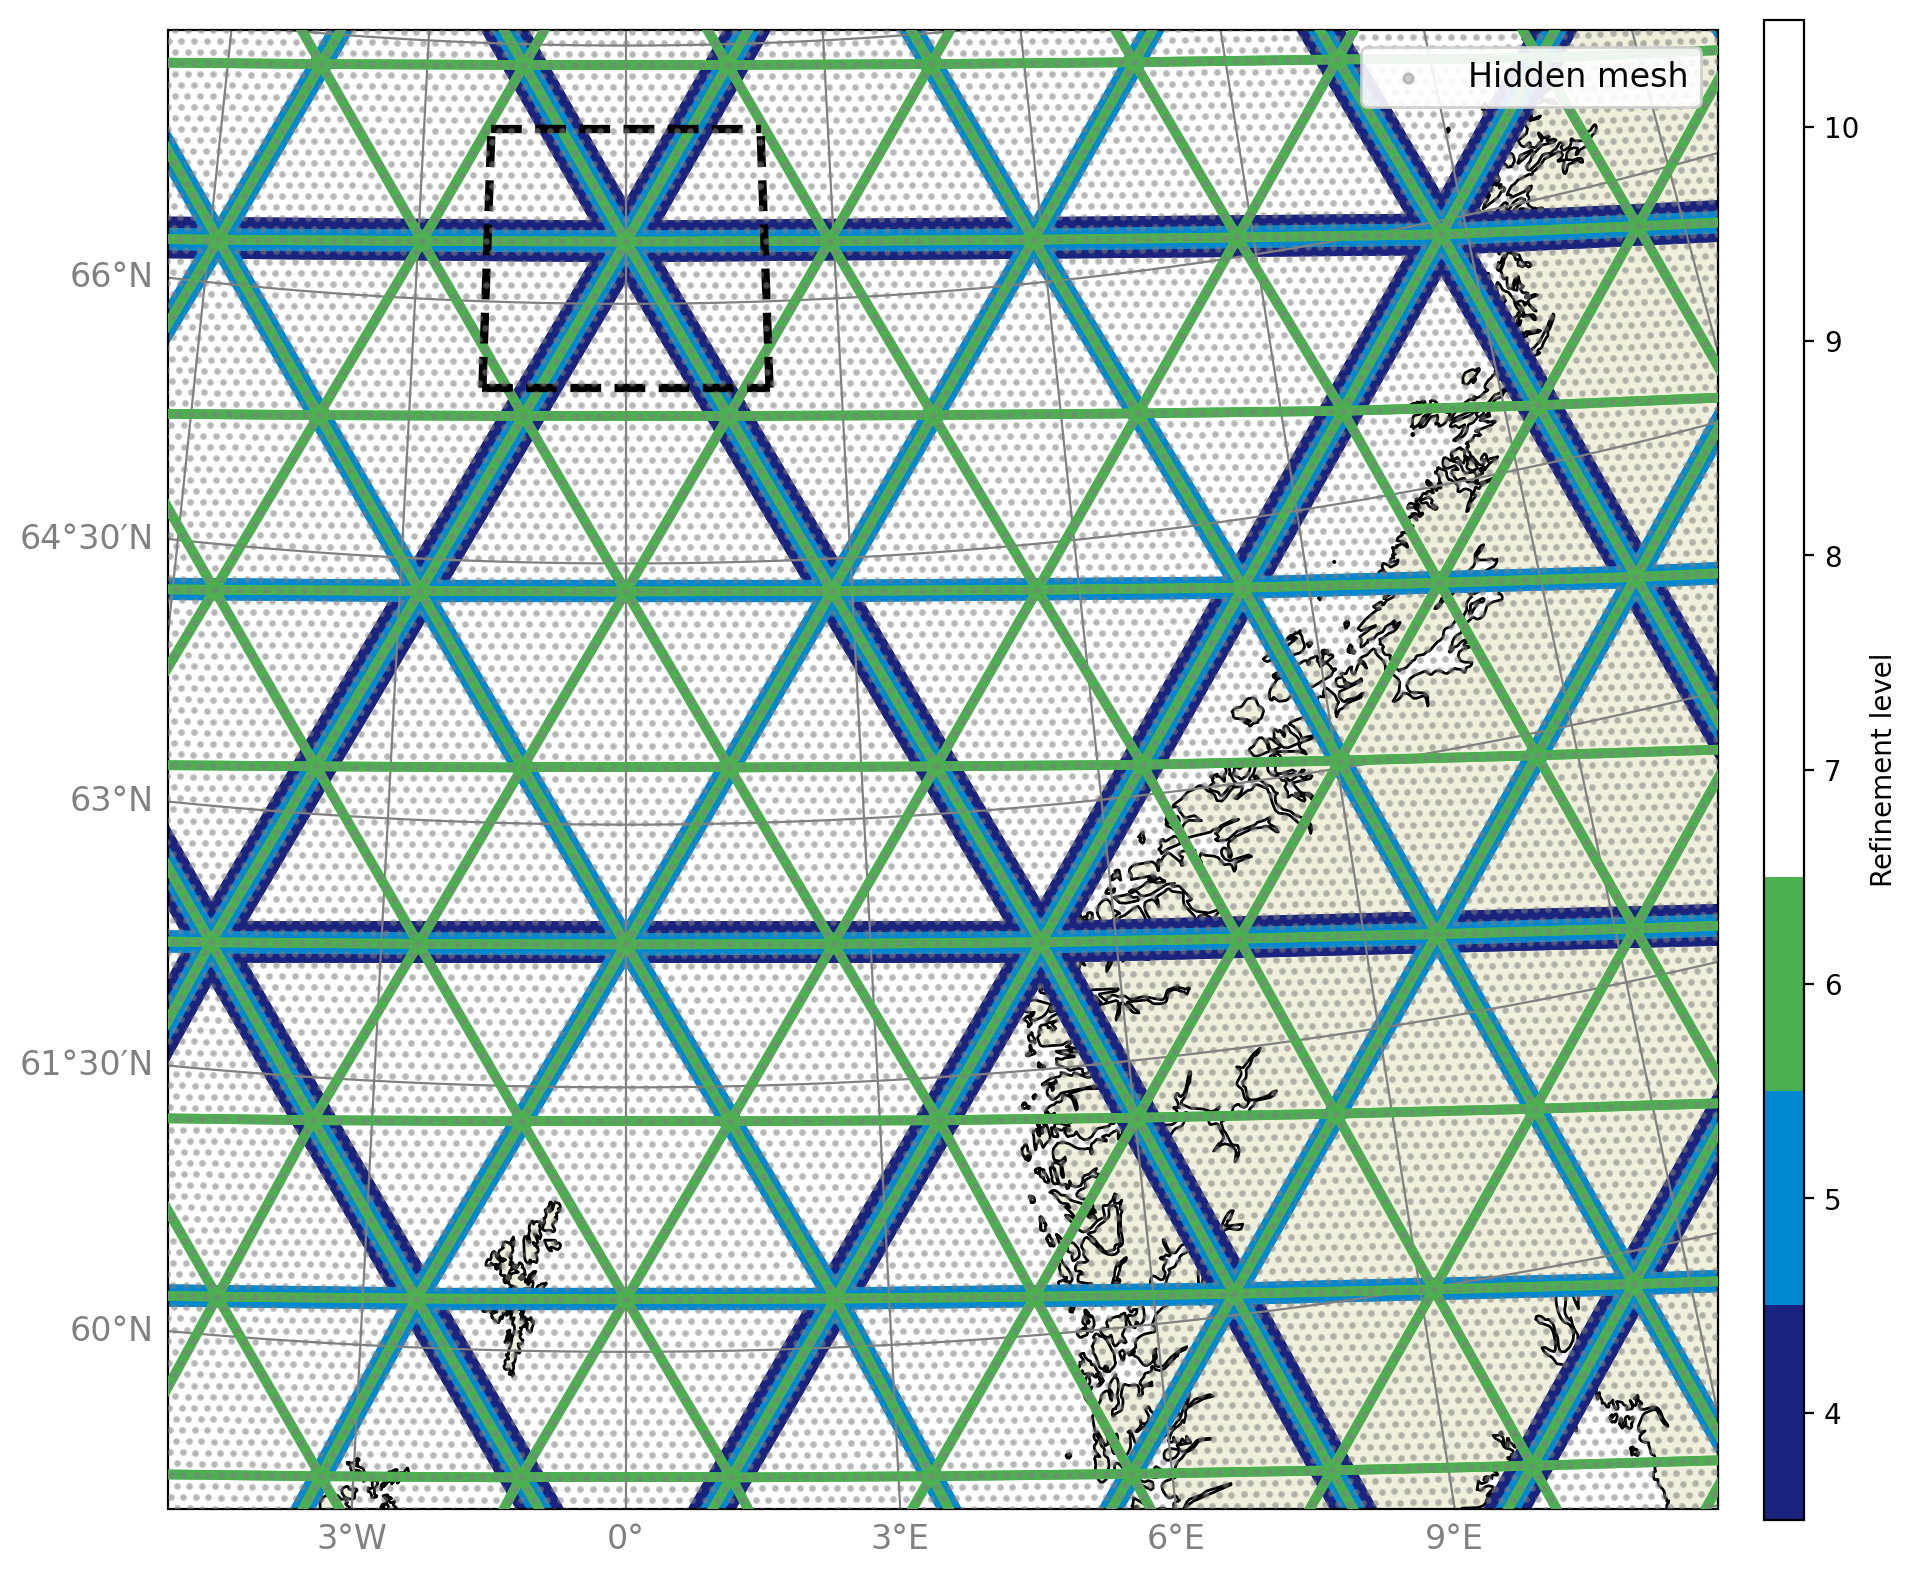

In [15]:
fig, ax = plt.subplots(figsize=(10,10), dpi=200, subplot_kw={'projection':ccrs.NorthPolarStereo()})
ax.scatter(graph.mesh_lons, graph.mesh_lats, marker='.', s=10, color='grey', label = 'Hidden mesh', transform=ccrs.PlateCarree(), zorder=50, alpha=0.4)

cmap = ['#1A237E', '#0288D1', '#4CAF50', '#FFFFFF', '#FFFFFF', '#FFFFFF', '#FFFFFF']
for i in range(n_lines):
    if edge_weights[i] < 8:
        pass
    else:
        color, lw, zorder = get_color(edge_weights[i], cmap=cmap)
        ax.plot(mesh_edge_lons_large[3*i:3*i+2], mesh_edge_lats_large[3*i:3*i+2], lw=lw, zorder=zorder, color=color, transform=ccrs.PlateCarree())

lons = [-2, 2]
lats = [65.5, 67]
ax.plot([lons[0], lons[0]], [lats[0], lats[1]], transform=ccrs.PlateCarree(), zorder=15, lw=3, ls='--', color='black')
ax.plot([lons[0], lons[1]], [lats[0], lats[0]], transform=ccrs.PlateCarree(), zorder=15, lw=3, ls='--', color='black')
ax.plot([lons[0], lons[1]], [lats[1], lats[1]], transform=ccrs.PlateCarree(), zorder=15, lw=3, ls='--', color='black')
ax.plot([lons[1], lons[1]], [lats[0], lats[1]], transform=ccrs.PlateCarree(), zorder=15, lw=3, ls='--', color='black')

custom_cmap = LinearSegmentedColormap.from_list("CustomCmap", cmap, N=7)
norm = mcolors.Normalize(vmin=1, vmax=8)

sm = cm.ScalarMappable(cmap=custom_cmap, norm=norm)
cax = fig.add_axes([ax.get_position().x1+0.07,ax.get_position().y0+0.01,0.02,ax.get_position().height-0.02])
cbar = fig.colorbar(sm, cax=cax, ticks=[1.5,2.5,3.5,4.5,5.5,6.5, 7.5], label='Refinement level')
cbar.ax.set_yticklabels(["4", "5", "6", "7", "8", "9", "10"])
ax.set_extent([-5,12,59,67.1])
ax.add_feature(cartopy.feature.LAND, zorder=0, edgecolor='black')
legend = ax.legend(loc='upper right', fontsize=12, framealpha=0.9)
legend.set_zorder(150)
for handle in legend.legend_handles:
    handle.set_sizes([50])

label_style = {'size': 12, 'color': 'gray'}
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='black', draw_labels=True, dms=True, x_inline=False, y_inline=False, zorder=200)
gl.top_labels = gl.right_labels = False
gl.xlabel_style = label_style
gl.ylabel_style = label_style
gl.rotate_labels = False
gl.xlines = gl.ylines = None
ax.gridlines(crs=ccrs.PlateCarree(), color='grey', draw_labels=False, x_inline=False, y_inline=False, zorder=0)